<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/revised_fair_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive



=== BASELINE XGBOOST ===
electricity_units_kwh MAE: 5.2128
power_outage_hours MAE: 1.1572
vulnerability_score MAE: 0.0632
Epoch 1, Loss: 22511.5036
Epoch 2, Loss: 5533.0882
Epoch 3, Loss: 3076.5315
Epoch 4, Loss: 2055.7713
Epoch 5, Loss: 1691.7567
Epoch 6, Loss: 1445.6716
Epoch 7, Loss: 1230.3483
Epoch 8, Loss: 1072.1281
Epoch 9, Loss: 944.7300
Epoch 10, Loss: 865.1782
Epoch 11, Loss: 807.8802
Epoch 12, Loss: 700.3624
Epoch 13, Loss: 705.2406
Epoch 14, Loss: 639.0489
Epoch 15, Loss: 625.5345
Epoch 16, Loss: 623.0446
Epoch 17, Loss: 558.7314
Epoch 18, Loss: 527.0630
Epoch 19, Loss: 496.3762
Epoch 20, Loss: 508.1592
Epoch 21, Loss: 467.4242
Epoch 22, Loss: 446.7588
Epoch 23, Loss: 467.9940
Epoch 24, Loss: 481.6953
Epoch 25, Loss: 448.6701
Epoch 26, Loss: 431.7245
Epoch 27, Loss: 419.4277
Epoch 28, Loss: 403.0962
Epoch 29, Loss: 430.5309
Epoch 30, Loss: 395.4522

=== FAIR MODEL ===
electricity_units_kwh MAE: 5.0118
power_outage_hours MAE: 1.0335
vulnerability_score MAE: 0.3464

=== FAIRN

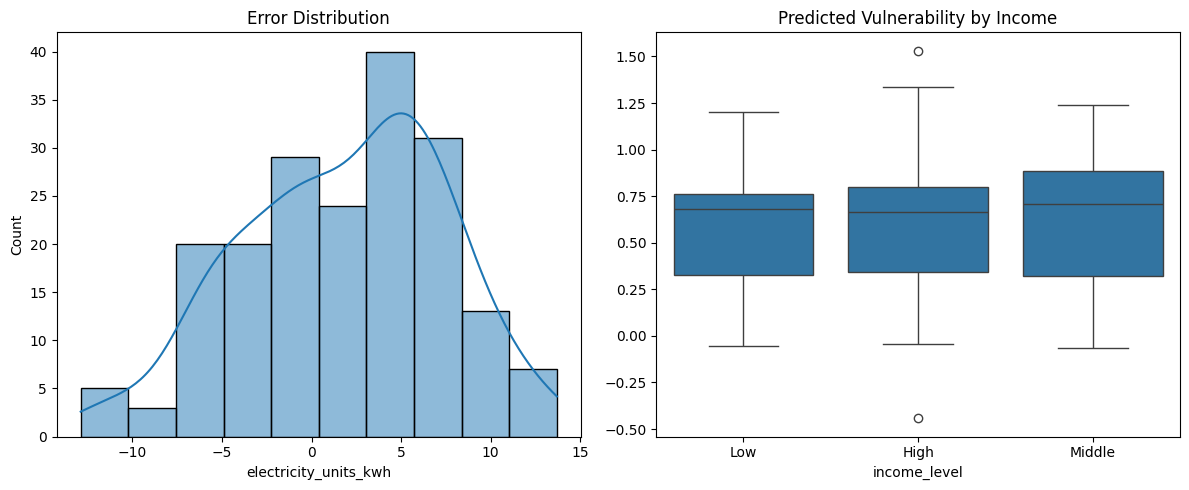

In [3]:
# ================= INSTALL =================
!pip install pandas numpy scikit-learn xgboost torch fairlearn matplotlib seaborn

# ================= IMPORTS =================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from fairlearn.metrics import demographic_parity_difference
import matplotlib.pyplot as plt
import seaborn as sns

# ================= LOAD DATA =================
df = pd.read_csv('/content/drive/MyDrive/Dataset/pakistan_household_electricity.csv')
df['date'] = pd.to_datetime(df['date'])

# ================= FEATURE ENGINEERING =================
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df = df.sort_values(['city', 'date'])

for lag in [1, 7]:
    df[f'consumption_lag_{lag}'] = df.groupby('city')['electricity_units_kwh'].shift(lag)
    df[f'outage_lag_{lag}'] = df.groupby('city')['power_outage_hours'].shift(lag)

df['consumption_roll_mean_7'] = df.groupby('city')['electricity_units_kwh'].transform(lambda x: x.rolling(7).mean())
df['temp_humidity_interaction'] = df['temperature_c'] * df['humidity_percent']

# Encoding
le_income = LabelEncoder()
le_city = LabelEncoder()

df['income_encoded'] = le_income.fit_transform(df['income_level'])
df['city_encoded'] = le_city.fit_transform(df['city'])

# ================= VULNERABILITY =================
df['norm_consumption'] = df['electricity_units_kwh'] / df['electricity_units_kwh'].max()
df['norm_outage'] = df['power_outage_hours'] / df['power_outage_hours'].max()

income_weight = {'Low':1.0,'Middle':0.6,'High':0.3}
df['income_weight'] = df['income_level'].map(income_weight)

df['vulnerability_score'] = (
    0.4*df['norm_consumption'] +
    0.4*df['norm_outage'] +
    0.2*df['income_weight']
)

# ================= SPLIT =================
feature_cols = [
    'temperature_c','humidity_percent','household_size','income_encoded',
    'city_encoded','year','month','day_of_week','is_weekend',
    'consumption_lag_1','consumption_lag_7','outage_lag_1','outage_lag_7',
    'consumption_roll_mean_7','temp_humidity_interaction'
]

target_cols = ['electricity_units_kwh','power_outage_hours','vulnerability_score']

df_model = df.dropna()

train = df_model[df_model['date'] < '2025-08-01']
test = df_model[df_model['date'] >= '2025-08-01']

X_train = train[feature_cols]
y_train = train[target_cols]
S_train = train['income_encoded']

X_test = test[feature_cols]
y_test = test[target_cols]
S_test = test['income_encoded']

# ================= BASELINE XGBOOST =================
xgb = MultiOutputRegressor(XGBRegressor(n_estimators=200))
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\n=== BASELINE XGBOOST ===")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:,i], y_pred_xgb[:,i])
    print(f"{col} MAE: {mae:.4f}")

# ================= DATASET =================
class EnergyDataset(Dataset):
    def __init__(self, X, y, s):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
        self.s = torch.tensor(s.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.s[idx]

train_loader = DataLoader(EnergyDataset(X_train, y_train, S_train), batch_size=64, shuffle=True)

# ================= GRADIENT REVERSAL =================
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

# ================= MODEL =================
class FairNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128,128),
            nn.ReLU()
        )
        self.task_heads = nn.ModuleList([nn.Linear(128,1) for _ in range(3)])
        self.adv = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,3)
        )

    def forward(self, x, alpha=0):
        shared = self.shared(x)

        # Task predictions
        task_out = torch.cat([h(shared) for h in self.task_heads], dim=1)

        # Adversarial branch
        rev = GradReverse.apply(shared, alpha)
        adv_out = self.adv(rev)

        return task_out, adv_out

# ================= TRAIN =================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FairNet(len(feature_cols)).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
mse = nn.MSELoss()
ce = nn.CrossEntropyLoss()

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    alpha = min(0.1, epoch/20)  # gradual increase

    for Xb, yb, sb in train_loader:
        Xb, yb, sb = Xb.to(device), yb.to(device), sb.to(device)

        optimizer.zero_grad()

        task_pred, adv_pred = model(Xb, alpha)

        loss_task = mse(task_pred, yb)
        loss_adv = ce(adv_pred, sb)

        loss = loss_task + alpha * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# ================= EVALUATION =================
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
    y_pred_nn, _ = model(X_test_t)
    y_pred_nn = y_pred_nn.cpu().numpy()

print("\n=== FAIR MODEL ===")
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test.iloc[:,i], y_pred_nn[:,i])
    print(f"{col} MAE: {mae:.4f}")

# ================= FAIRNESS =================
print("\n=== FAIRNESS COMPARISON ===")

for i, col in enumerate(target_cols):
    # Baseline
    base_bin = (y_pred_xgb[:,i] > y_pred_xgb[:,i].mean()).astype(int)
    fair_bin = (y_pred_nn[:,i] > y_pred_nn[:,i].mean()).astype(int)
    true_bin = (y_test.iloc[:,i] > y_test.iloc[:,i].mean()).astype(int)

    dp_base = demographic_parity_difference(true_bin, base_bin, sensitive_features=S_test)
    dp_fair = demographic_parity_difference(true_bin, fair_bin, sensitive_features=S_test)

    print(f"{col}")
    print(f"  XGB DPD : {dp_base:.4f}")
    print(f"  FairNN  : {dp_fair:.4f}")

# ================= PLOTS =================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_test['electricity_units_kwh'] - y_pred_nn[:,0], kde=True)
plt.title("Error Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=test['income_level'], y=y_pred_nn[:,2])
plt.title("Predicted Vulnerability by Income")

plt.tight_layout()
plt.savefig("final_results.png", dpi=300)
print("✅ Saved final_results.png")

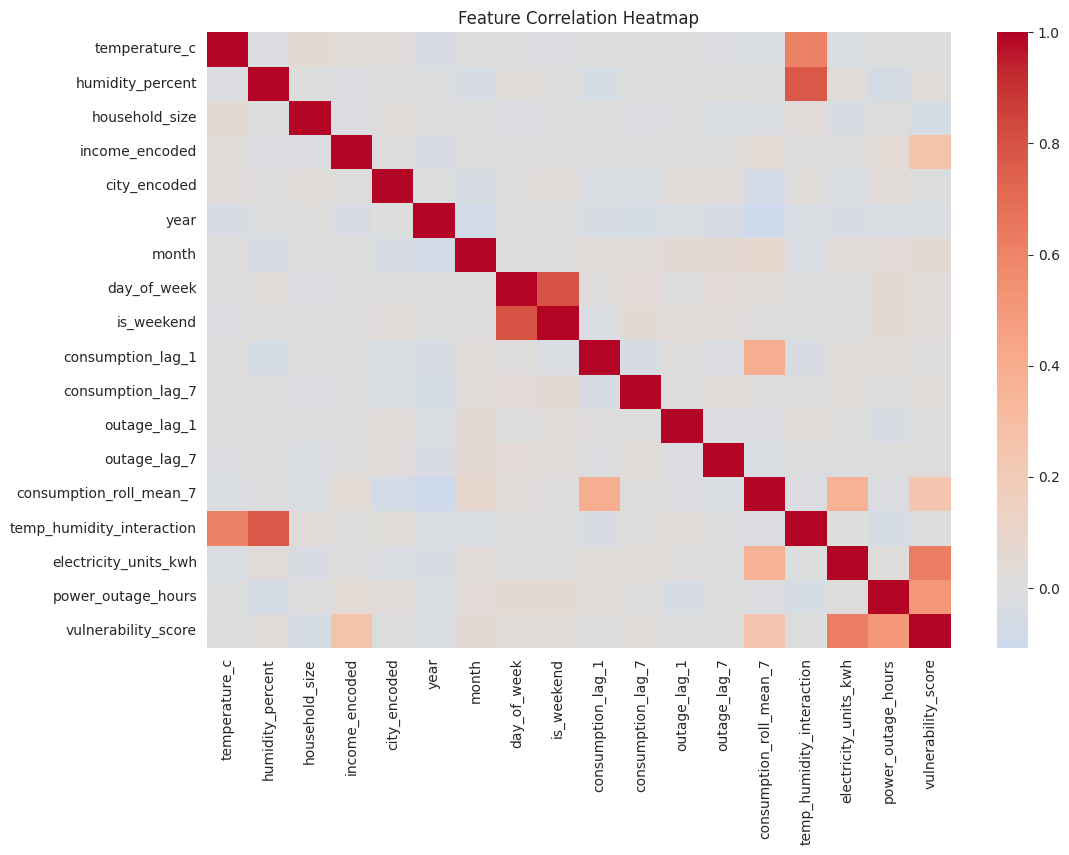

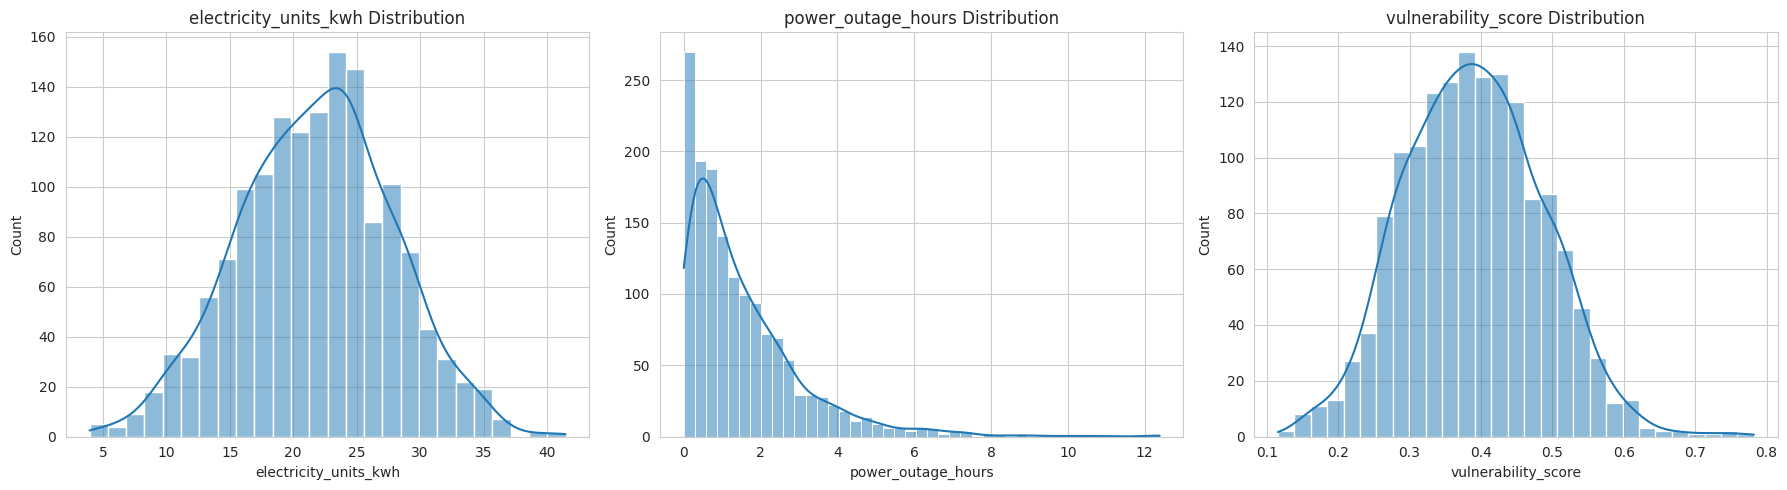

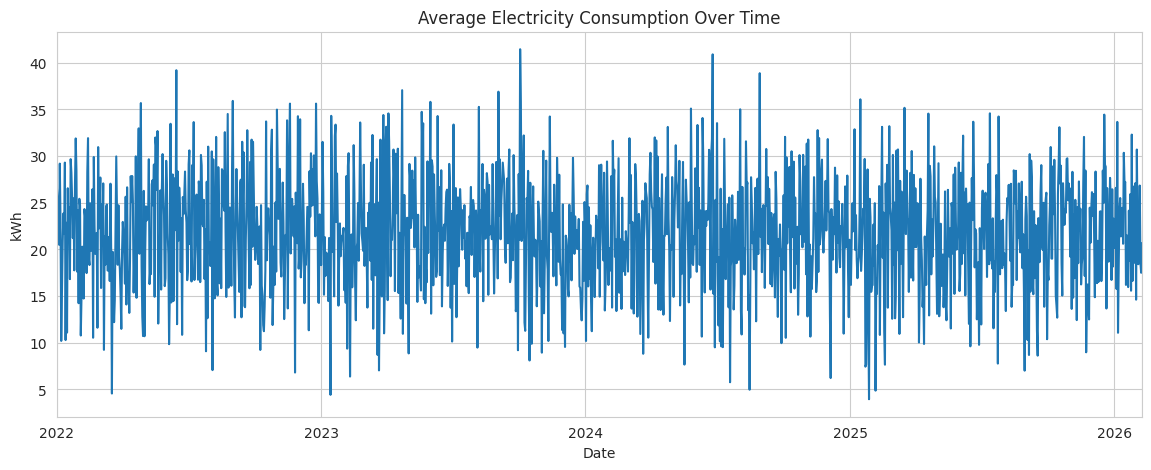

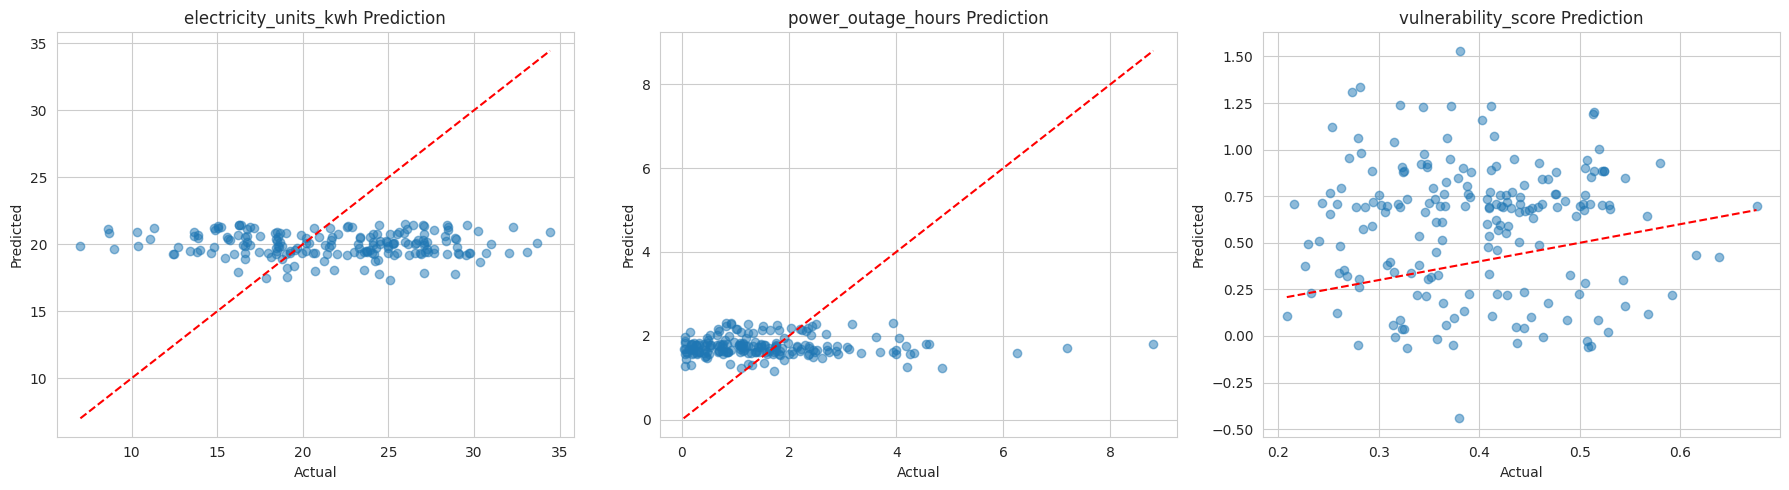

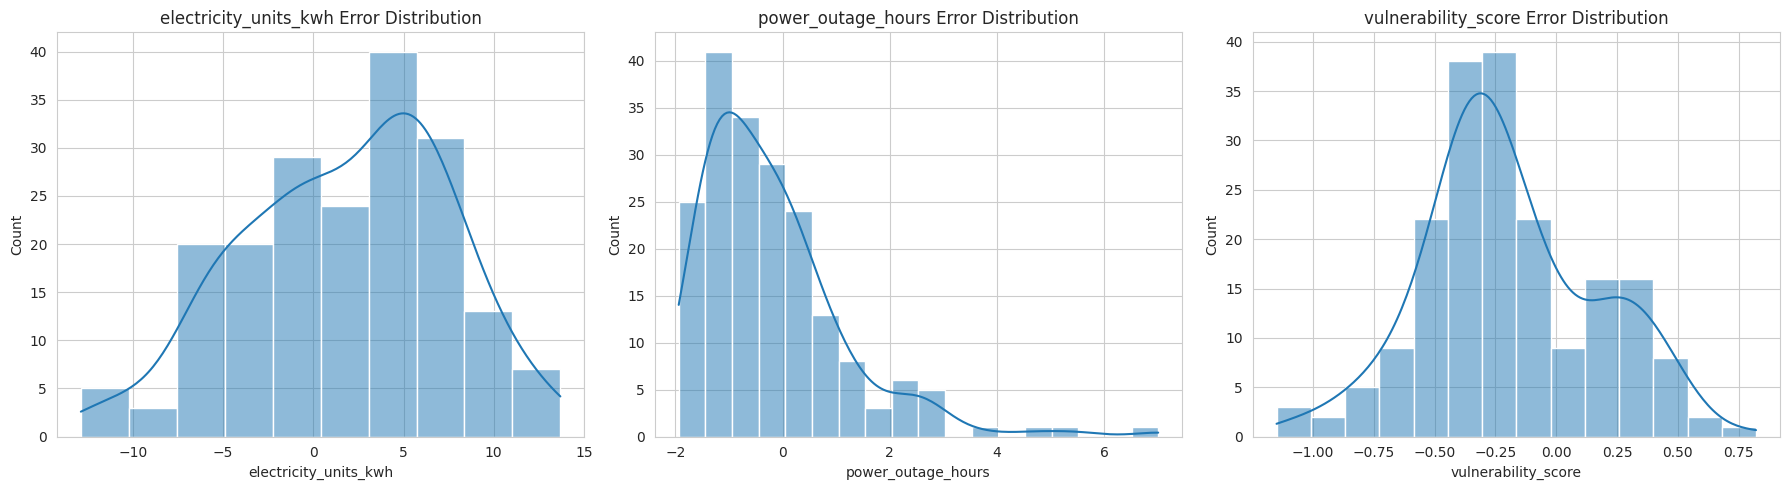

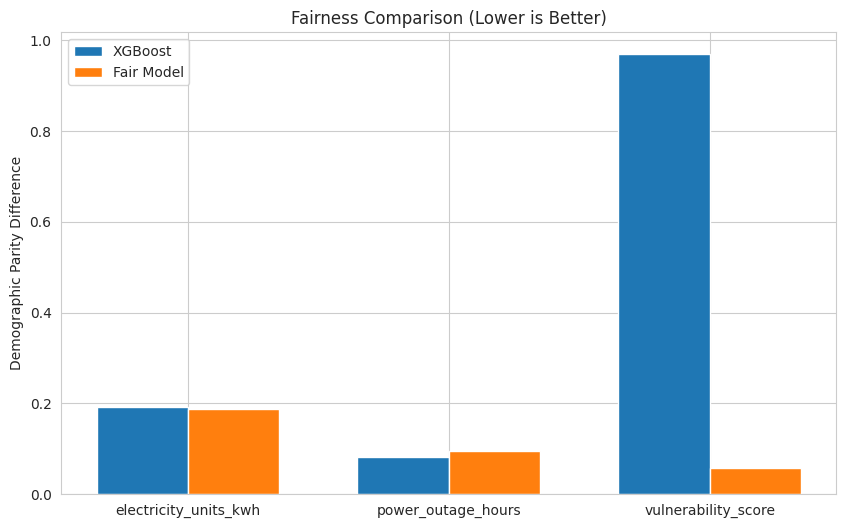

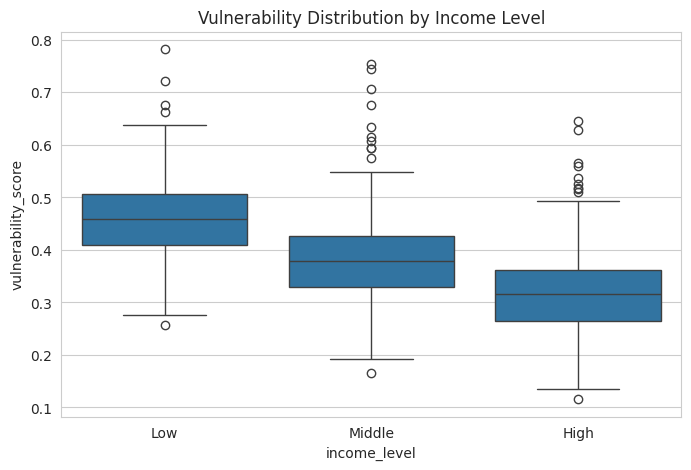

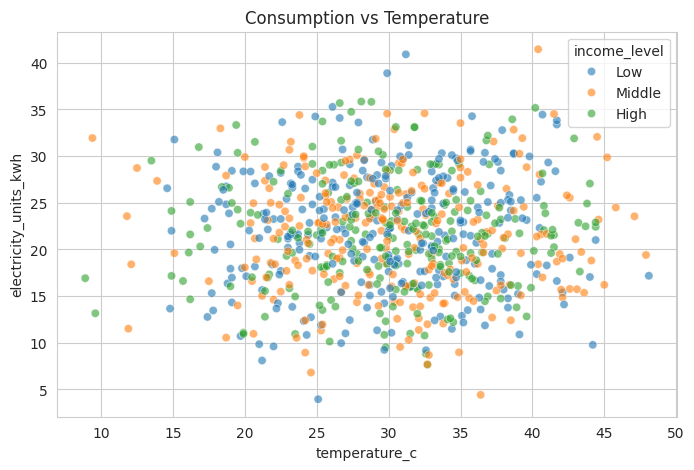

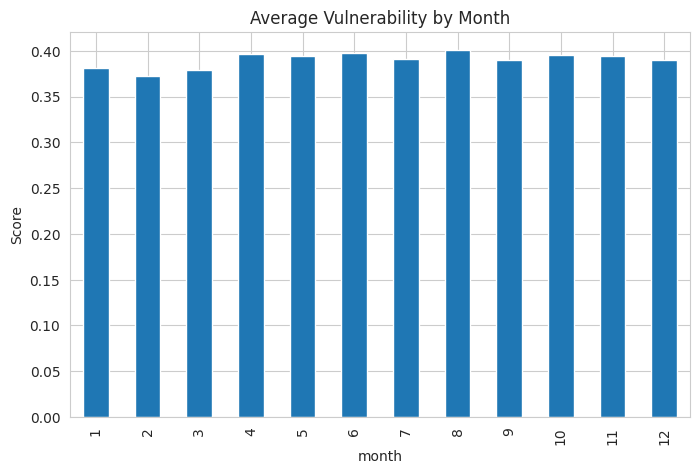

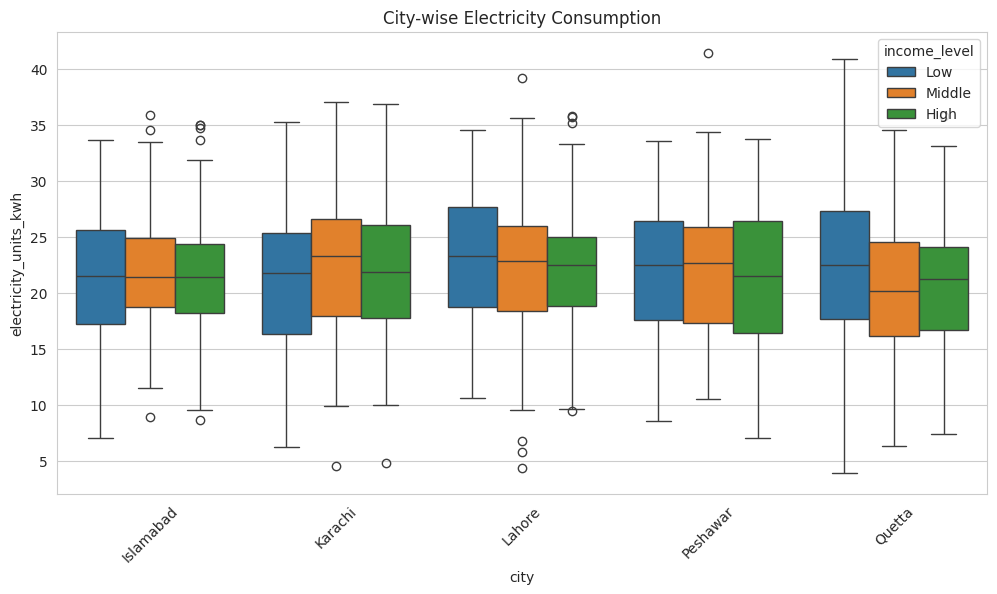

✅ All plots generated successfully!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# ================= 1. CORRELATION HEATMAP =================
plt.figure(figsize=(12,8))
corr = df[feature_cols + target_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.savefig("fig1_correlation_heatmap.png", dpi=300)
plt.show()

# ================= 2. TARGET DISTRIBUTIONS =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")

plt.tight_layout()
plt.savefig("fig2_target_distribution.png", dpi=300)
plt.show()

# ================= 3. TIME SERIES TREND =================
plt.figure(figsize=(14,5))
df.groupby('date')['electricity_units_kwh'].mean().plot()
plt.title("Average Electricity Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.savefig("fig3_timeseries.png", dpi=300)
plt.show()

# ================= 4. ACTUAL vs PREDICTED =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    axes[i].scatter(y_test.iloc[:,i], y_pred_nn[:,i], alpha=0.5)
    axes[i].plot([y_test.iloc[:,i].min(), y_test.iloc[:,i].max()],
                 [y_test.iloc[:,i].min(), y_test.iloc[:,i].max()], 'r--')
    axes[i].set_title(f"{col} Prediction")
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

plt.tight_layout()
plt.savefig("fig4_prediction_vs_actual.png", dpi=300)
plt.show()

# ================= 5. ERROR DISTRIBUTION =================
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(target_cols):
    errors = y_test.iloc[:,i] - y_pred_nn[:,i]
    sns.histplot(errors, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Error Distribution")

plt.tight_layout()
plt.savefig("fig5_error_distribution.png", dpi=300)
plt.show()

# ================= 6. FAIRNESS COMPARISON =================
dpd_xgb = []
dpd_fair = []

for i in range(3):
    base_bin = (y_pred_xgb[:,i] > y_pred_xgb[:,i].mean()).astype(int)
    fair_bin = (y_pred_nn[:,i] > y_pred_nn[:,i].mean()).astype(int)
    true_bin = (y_test.iloc[:,i] > y_test.iloc[:,i].mean()).astype(int)

    dp_base = demographic_parity_difference(true_bin, base_bin, sensitive_features=S_test)
    dp_fair_val = demographic_parity_difference(true_bin, fair_bin, sensitive_features=S_test)

    dpd_xgb.append(dp_base)
    dpd_fair.append(dp_fair_val)

x = np.arange(len(target_cols))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, dpd_xgb, width, label='XGBoost')
plt.bar(x + width/2, dpd_fair, width, label='Fair Model')

plt.xticks(x, target_cols)
plt.ylabel("Demographic Parity Difference")
plt.title("Fairness Comparison (Lower is Better)")
plt.legend()

plt.savefig("fig6_fairness_comparison.png", dpi=300)
plt.show()

# ================= 7. VULNERABILITY BY INCOME =================
plt.figure(figsize=(8,5))
sns.boxplot(x='income_level', y='vulnerability_score', data=df)
plt.title("Vulnerability Distribution by Income Level")
plt.savefig("fig7_vulnerability_income.png", dpi=300)
plt.show()

# ================= 8. CONSUMPTION vs TEMPERATURE =================
plt.figure(figsize=(8,5))
sns.scatterplot(x='temperature_c', y='electricity_units_kwh',
                hue='income_level', data=df.sample(800), alpha=0.6)
plt.title("Consumption vs Temperature")
plt.savefig("fig8_temp_vs_consumption.png", dpi=300)
plt.show()

# ================= 9. MONTHLY VULNERABILITY =================
monthly_vuln = df.groupby('month')['vulnerability_score'].mean()

plt.figure(figsize=(8,5))
monthly_vuln.plot(kind='bar')
plt.title("Average Vulnerability by Month")
plt.ylabel("Score")
plt.savefig("fig9_monthly_vulnerability.png", dpi=300)
plt.show()

# ================= 10. CITY LEVEL ANALYSIS =================
plt.figure(figsize=(12,6))
sns.boxplot(x='city', y='electricity_units_kwh', hue='income_level', data=df)
plt.xticks(rotation=45)
plt.title("City-wise Electricity Consumption")
plt.savefig("fig10_city_analysis.png", dpi=300)
plt.show()

print("✅ All plots generated successfully!")

In [1]:
!pip install shap

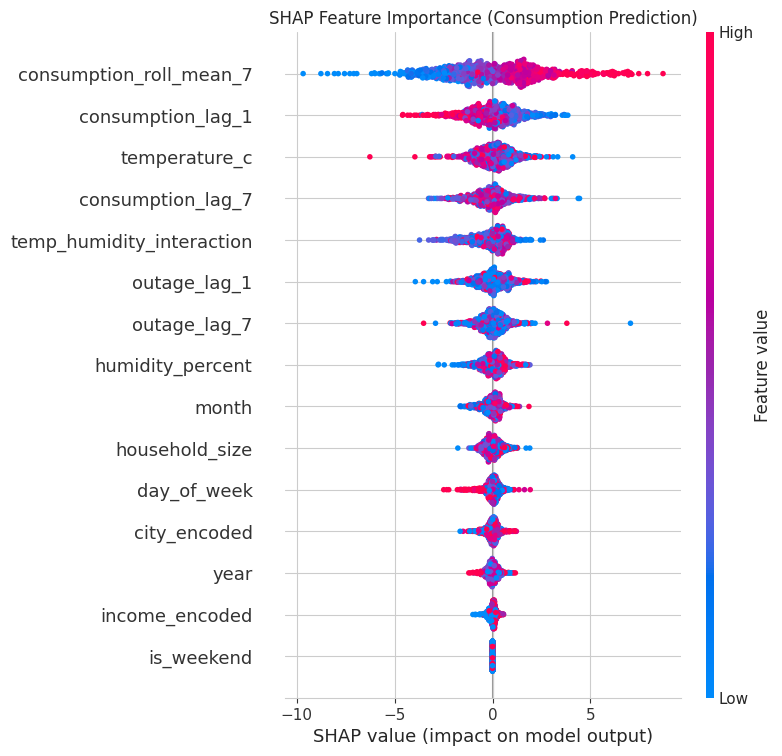

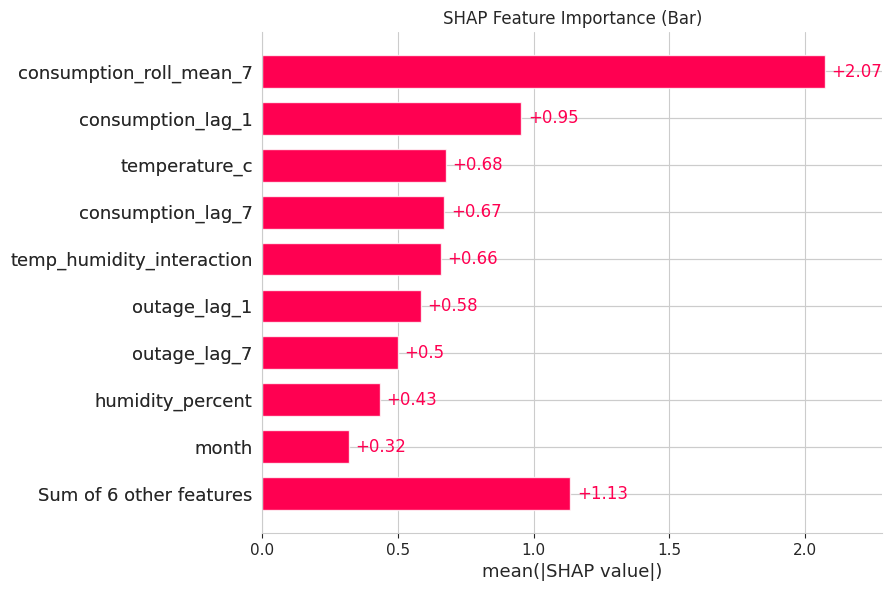

In [5]:
import shap

# Use a smaller sample (SHAP is heavy)
X_sample = X_train.sample(1000, random_state=42)

# Train single-output model for SHAP (for consumption)
from xgboost import XGBRegressor
model_shap = XGBRegressor(n_estimators=200)
model_shap.fit(X_train, y_train['electricity_units_kwh'])

explainer = shap.Explainer(model_shap)
shap_values = explainer(X_sample)

# Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance (Consumption Prediction)")
plt.savefig("fig_shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# Bar Plot
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.savefig("fig_shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()

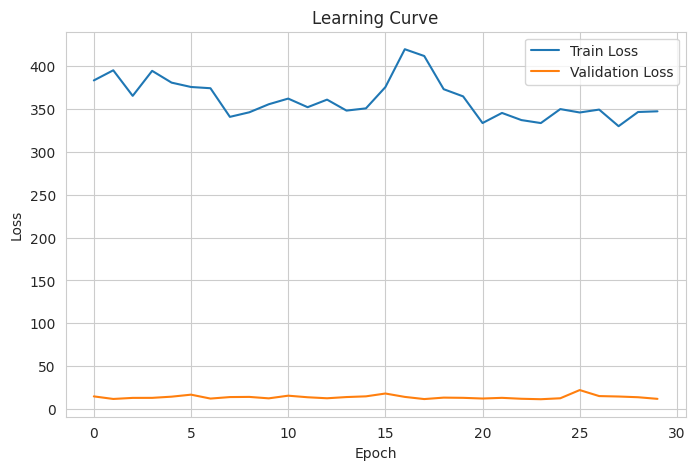

In [6]:
train_losses = []
val_losses = []

for epoch in range(30):
    model.train()
    epoch_loss = 0

    for Xb, yb, sb in train_loader:
        Xb, yb, sb = Xb.to(device), yb.to(device), sb.to(device)

        optimizer.zero_grad()
        pred, adv = model(Xb, alpha=0.05)

        loss = mse(pred, yb) + 0.05 * ce(adv, sb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        X_val = torch.tensor(X_test.values, dtype=torch.float32).to(device)
        y_val = torch.tensor(y_test.values, dtype=torch.float32).to(device)

        pred_val, _ = model(X_val)
        val_loss = mse(pred_val, y_val).item()
        val_losses.append(val_loss)

# Plot
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve")
plt.legend()
plt.savefig("fig_learning_curve.png", dpi=300)
plt.show()

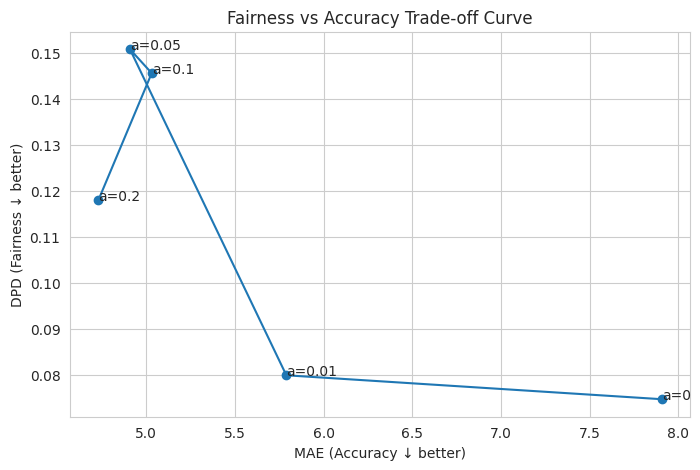

In [7]:
alphas = [0, 0.01, 0.05, 0.1, 0.2]

mae_list = []
dpd_list = []

for alpha in alphas:
    model = FairNet(len(feature_cols)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(10):
        model.train()
        for Xb, yb, sb in train_loader:
            Xb, yb, sb = Xb.to(device), yb.to(device), sb.to(device)

            optimizer.zero_grad()
            pred, adv = model(Xb, alpha)

            loss = mse(pred, yb) + alpha * ce(adv, sb)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        pred, _ = model(X_test_t)
        pred = pred.cpu().numpy()

    mae = mean_absolute_error(y_test.iloc[:,0], pred[:,0])
    mae_list.append(mae)

    pred_bin = (pred[:,0] > pred[:,0].mean()).astype(int)
    true_bin = (y_test.iloc[:,0] > y_test.iloc[:,0].mean()).astype(int)

    dpd = demographic_parity_difference(true_bin, pred_bin, sensitive_features=S_test)
    dpd_list.append(dpd)

# Plot trade-off
plt.figure(figsize=(8,5))
plt.plot(mae_list, dpd_list, marker='o')
plt.xlabel("MAE (Accuracy ↓ better)")
plt.ylabel("DPD (Fairness ↓ better)")
plt.title("Fairness vs Accuracy Trade-off Curve")

for i, alpha in enumerate(alphas):
    plt.annotate(f"a={alpha}", (mae_list[i], dpd_list[i]))

plt.savefig("fig_tradeoff.png", dpi=300)
plt.show()